# Day-Ahead Electricity Price Forecasting with LightGBM + Optuna

## Project Overview
This notebook builds a robust **machine learning model** to forecast **next-day (day-ahead) hourly electricity prices** using 2023 ENTSO-E data.

The model combines strong feature engineering with **hyperparameter optimization** using Optuna to achieve better performance.

## Process Steps

1. **Load the Data**  
   Read the CSV file and convert timestamps to proper datetime format.

2. **Feature Engineering**  
   Create rich features that capture patterns in electricity prices:
   - Time-based features (hour, day of week, month, weekend)
   - Lag features (prices from previous hours/days up to 1 week)
   - Rolling statistics (mean and standard deviation)
   - Domain-specific features (same hour yesterday and last week)

3. **Train-Test Split**  
   Use a **temporal split** (last 14 days as test set) to realistically simulate day-ahead forecasting and avoid data leakage.

4. **Hyperparameter Tuning with Optuna**  
   Automatically search for the best LightGBM hyperparameters using Optuna (Bayesian optimization).  
   This step significantly improves model performance compared to default parameters.

5. **Train Final Model**  
   Train the LightGBM model using the best hyperparameters found during tuning.

6. **Evaluation**  
   Measure model performance using **MAE** and **RMSE** on the unseen test period.

7. **Results & Visualization**  
   Plot actual vs predicted prices, error analysis, daily profiles, and feature importance.

**Goal**: Build a practical, accurate, and explainable forecasting model that can support real-world energy trading, demand planning, and risk management decisions.

Data loaded: 9,001 rows from 2022-12-31 to 2024-01-01
Features created. Total features: 25
Training data: 8499 rows
Test data (last 14 days): 334 rows
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 8.55232
Early stopping, best iteration is:
[179]	valid_0's l1: 8.48464

✅ Model Performance on last 14 days:
MAE  = 8.485 €/MWh
RMSE = 10.927 €/MWh

Top 10 Most Important Features:
                      feature    importance
4                 price_lag_1  1.090654e+08
5                 price_lag_2  3.819989e+07
9                price_lag_24  9.543607e+06
0                        hour  7.444644e+06
6                 price_lag_3  5.123933e+06
13          price_roll_std_24  4.687839e+06
18  price_same_hour_yesterday  1.754827e+06
12         price_roll_mean_24  1.413327e+06
7                 price_lag_6  1.307415e+06
8                price_lag_12  1.032972e+06


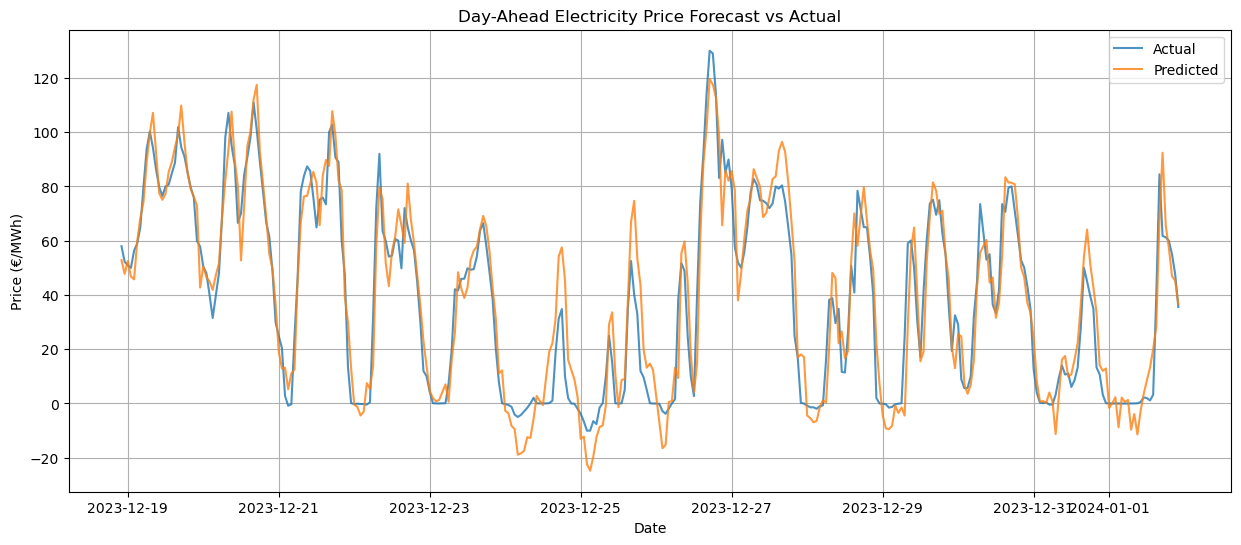

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ========================== 1. LOAD DATA ==========================
df = pd.read_csv('entsoe_prices_2023.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Data loaded: {df.shape[0]:,} rows from {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")


# ========================== 2. FEATURE ENGINEERING ==========================
def create_features(df):
    df = df.copy()
    
    # Basic time features
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Lag features (past prices)
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:   # up to 1 week
        df[f'price_lag_{lag}'] = df['price'].shift(lag)
    
    # Rolling window statistics
    for window in [24, 48, 168]:
        df[f'price_roll_mean_{window}'] = df['price'].rolling(window).mean()
        df[f'price_roll_std_{window}'] = df['price'].rolling(window).std()
    
    # Important domain features for electricity prices
    df['price_same_hour_yesterday'] = df['price'].shift(24)
    df['price_same_hour_last_week'] = df['price'].shift(168)
    
    return df


df = create_features(df)
df = df.dropna().reset_index(drop=True)   # Remove rows with missing values

print(f"Features created. Total features: {df.shape[1]}")


# ========================== 3. TRAIN-TEST SPLIT ==========================
test_days = 14
split_date = df['timestamp'].max() - pd.Timedelta(days=test_days)

train = df[df['timestamp'] < split_date]
test = df[df['timestamp'] >= split_date]

print(f"Training data: {train.shape[0]} rows")
print(f"Test data (last {test_days} days): {test.shape[0]} rows")


# ========================== 4. SELECT FEATURES ==========================
feature_cols = [col for col in df.columns 
                if col not in ['price', 'timestamp', 'period_start', 'period_end', 'position']]

X_train = train[feature_cols]
y_train = train['price']
X_test = test[feature_cols]
y_test = test['price']


# ========================== 5. TRAIN LIGHTGBM MODEL ==========================
params = {
    'objective': 'regression',
    'metric': 'mae',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'verbose': -1,
    'random_state': 42
}

model = lgb.train(
    params,
    lgb.Dataset(X_train, y_train),
    num_boost_round=2000,
    valid_sets=[lgb.Dataset(X_test, y_test)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

# ========================== 6. PREDICT & EVALUATE ==========================
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n✅ Model Performance on last {test_days} days:")
print(f"MAE  = {mae:.3f} €/MWh")
print(f"RMSE = {rmse:.3f} €/MWh")


# ========================== 7. FEATURE IMPORTANCE ==========================
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance.head(10))
# ========================== 7. PLOT RESULTS ==========================
plt.figure(figsize=(15, 6))
plt.plot(test['timestamp'], y_test, label='Actual', alpha=0.8)
plt.plot(test['timestamp'], y_pred, label='Predicted', alpha=0.8)
plt.title('Day-Ahead Electricity Price Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True)
plt.show()

# Day-Ahead Electricity Price Forecasting using LightGBM + Optuna

## Objective
Build a strong machine learning model to forecast **next-day hourly electricity prices** using 2023 ENTSO-E data.

## Process Steps (Clear & Detailed)

1. **Load the Data** – Read CSV and prepare timestamp  
2. **Feature Engineering** – Create time, lag, and statistical features  
3. **Train-Test Split** – Use last 14 days as test set (realistic temporal split)  
4. **Hyperparameter Tuning** – Use **Optuna** to automatically find the best model settings  
5. **Train Final Model** – Train LightGBM with the best parameters  
6. **Evaluation & Visualization** – Check performance and create multiple plots  

This approach combines good feature engineering with smart hyperparameter optimization.

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
import optuna
warnings.filterwarnings('ignore')

# ========================== 1. LOAD DATA ==========================
df = pd.read_csv('entsoe_prices_2023.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# ========================== 2. FEATURE ENGINEERING ==========================
def create_features(df):
    df = df.copy()
    
    # Time features
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    
    # Lag features
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        df[f'price_lag_{lag}'] = df['price'].shift(lag)
    
    # Rolling statistics
    for window in [24, 48, 168]:
        df[f'price_roll_mean_{window}'] = df['price'].rolling(window).mean()
        df[f'price_roll_std_{window}'] = df['price'].rolling(window).std()
    
    # Same hour previous day / week
    df['price_same_hour_yesterday'] = df['price'].shift(24)
    df['price_same_hour_last_week'] = df['price'].shift(168)
    
    return df

df = create_features(df)
df = df.dropna().reset_index(drop=True)

# ========================== 3. TRAIN-TEST SPLIT ==========================
test_days = 14
split_date = df['timestamp'].max() - pd.Timedelta(days=test_days)

train = df[df['timestamp'] < split_date]
test = df[df['timestamp'] >= split_date]

feature_cols = [col for col in df.columns 
                if col not in ['price', 'timestamp', 'period_start', 'period_end', 'position']]

X_train = train[feature_cols]
y_train = train['price']
X_test = test[feature_cols]
y_test = test['price']

# ========================== 4. OPTUNA HYPERPARAMETER TUNING ==========================
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 16, 128),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'verbose': -1,
        'random_state': 42
    }
    
    train_set = lgb.Dataset(X_train, y_train)
    valid_set = lgb.Dataset(X_test, y_test, reference=train_set)
    
    model = lgb.train(
        params,
        train_set,
        num_boost_round=2000,
        valid_sets=[valid_set],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    return mae


# Run Optuna optimization
print("Starting hyperparameter tuning with Optuna...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=1800)  # 50 trials or 30 minutes max

print(f"\n✅ Best trial MAE: {study.best_value:.4f}")
print("Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# ========================== 5. TRAIN FINAL MODEL WITH BEST PARAMS ==========================
best_params = study.best_params
best_params.update({
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'random_state': 42
})

final_model = lgb.train(
    best_params,
    lgb.Dataset(X_train, y_train),
    num_boost_round=2000,
    valid_sets=[lgb.Dataset(X_test, y_test)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

# ========================== 6. EVALUATION ==========================
y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n🎯 Final Model Performance (Last {test_days} days):")
print(f"MAE  = {mae:.3f} €/MWh")
print(f"RMSE = {rmse:.3f} €/MWh")

# Feature Importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

[I 2026-05-20 18:13:55,060] A new study created in memory with name: no-name-797a40ee-6d3f-46bf-b9a6-2bd523aad20c


Starting hyperparameter tuning with Optuna...


[I 2026-05-20 18:17:13,261] Trial 0 finished with value: 8.586836197819922 and parameters: {'learning_rate': 0.011945934720333645, 'num_leaves': 54, 'max_depth': 5, 'min_child_samples': 72, 'feature_fraction': 0.6015696760058459, 'bagging_fraction': 0.6882263132539513, 'bagging_freq': 3, 'lambda_l1': 5.716261393509273e-08, 'lambda_l2': 8.778447755813118e-05}. Best is trial 0 with value: 8.586836197819922.
[I 2026-05-20 18:20:12,638] Trial 1 finished with value: 8.521878753993876 and parameters: {'learning_rate': 0.015183930827750167, 'num_leaves': 118, 'max_depth': 6, 'min_child_samples': 21, 'feature_fraction': 0.7540519289050958, 'bagging_fraction': 0.6250821452965322, 'bagging_freq': 3, 'lambda_l1': 1.0682867418091397e-05, 'lambda_l2': 7.713913532667604e-06}. Best is trial 1 with value: 8.521878753993876.
[I 2026-05-20 18:21:20,251] Trial 2 finished with value: 8.835507897661566 and parameters: {'learning_rate': 0.02769271926195055, 'num_leaves': 84, 'max_depth': 5, 'min_child_sampl


✅ Best trial MAE: 8.2309
Best hyperparameters:
  learning_rate: 0.017332152143081855
  num_leaves: 117
  max_depth: 8
  min_child_samples: 5
  feature_fraction: 0.921361989822679
  bagging_fraction: 0.9961587480483858
  bagging_freq: 1
  lambda_l1: 1.6012630890103004e-06
  lambda_l2: 0.12956165936496702
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l1: 9.35964
[400]	valid_0's l1: 8.31329
Early stopping, best iteration is:
[305]	valid_0's l1: 8.23085

🎯 Final Model Performance (Last 14 days):
MAE  = 8.231 €/MWh
RMSE = 10.881 €/MWh

Top 10 Important Features:
               feature    importance
4          price_lag_1  4.048298e+08
5          price_lag_2  4.584327e+07
0                 hour  1.885919e+07
13   price_roll_std_24  1.383355e+07
9         price_lag_24  1.195689e+07
6          price_lag_3  1.168462e+07
12  price_roll_mean_24  3.345748e+06
7          price_lag_6  3.271931e+06
15   price_roll_std_48  3.073332e+06
1          day_of_week  2.451348e

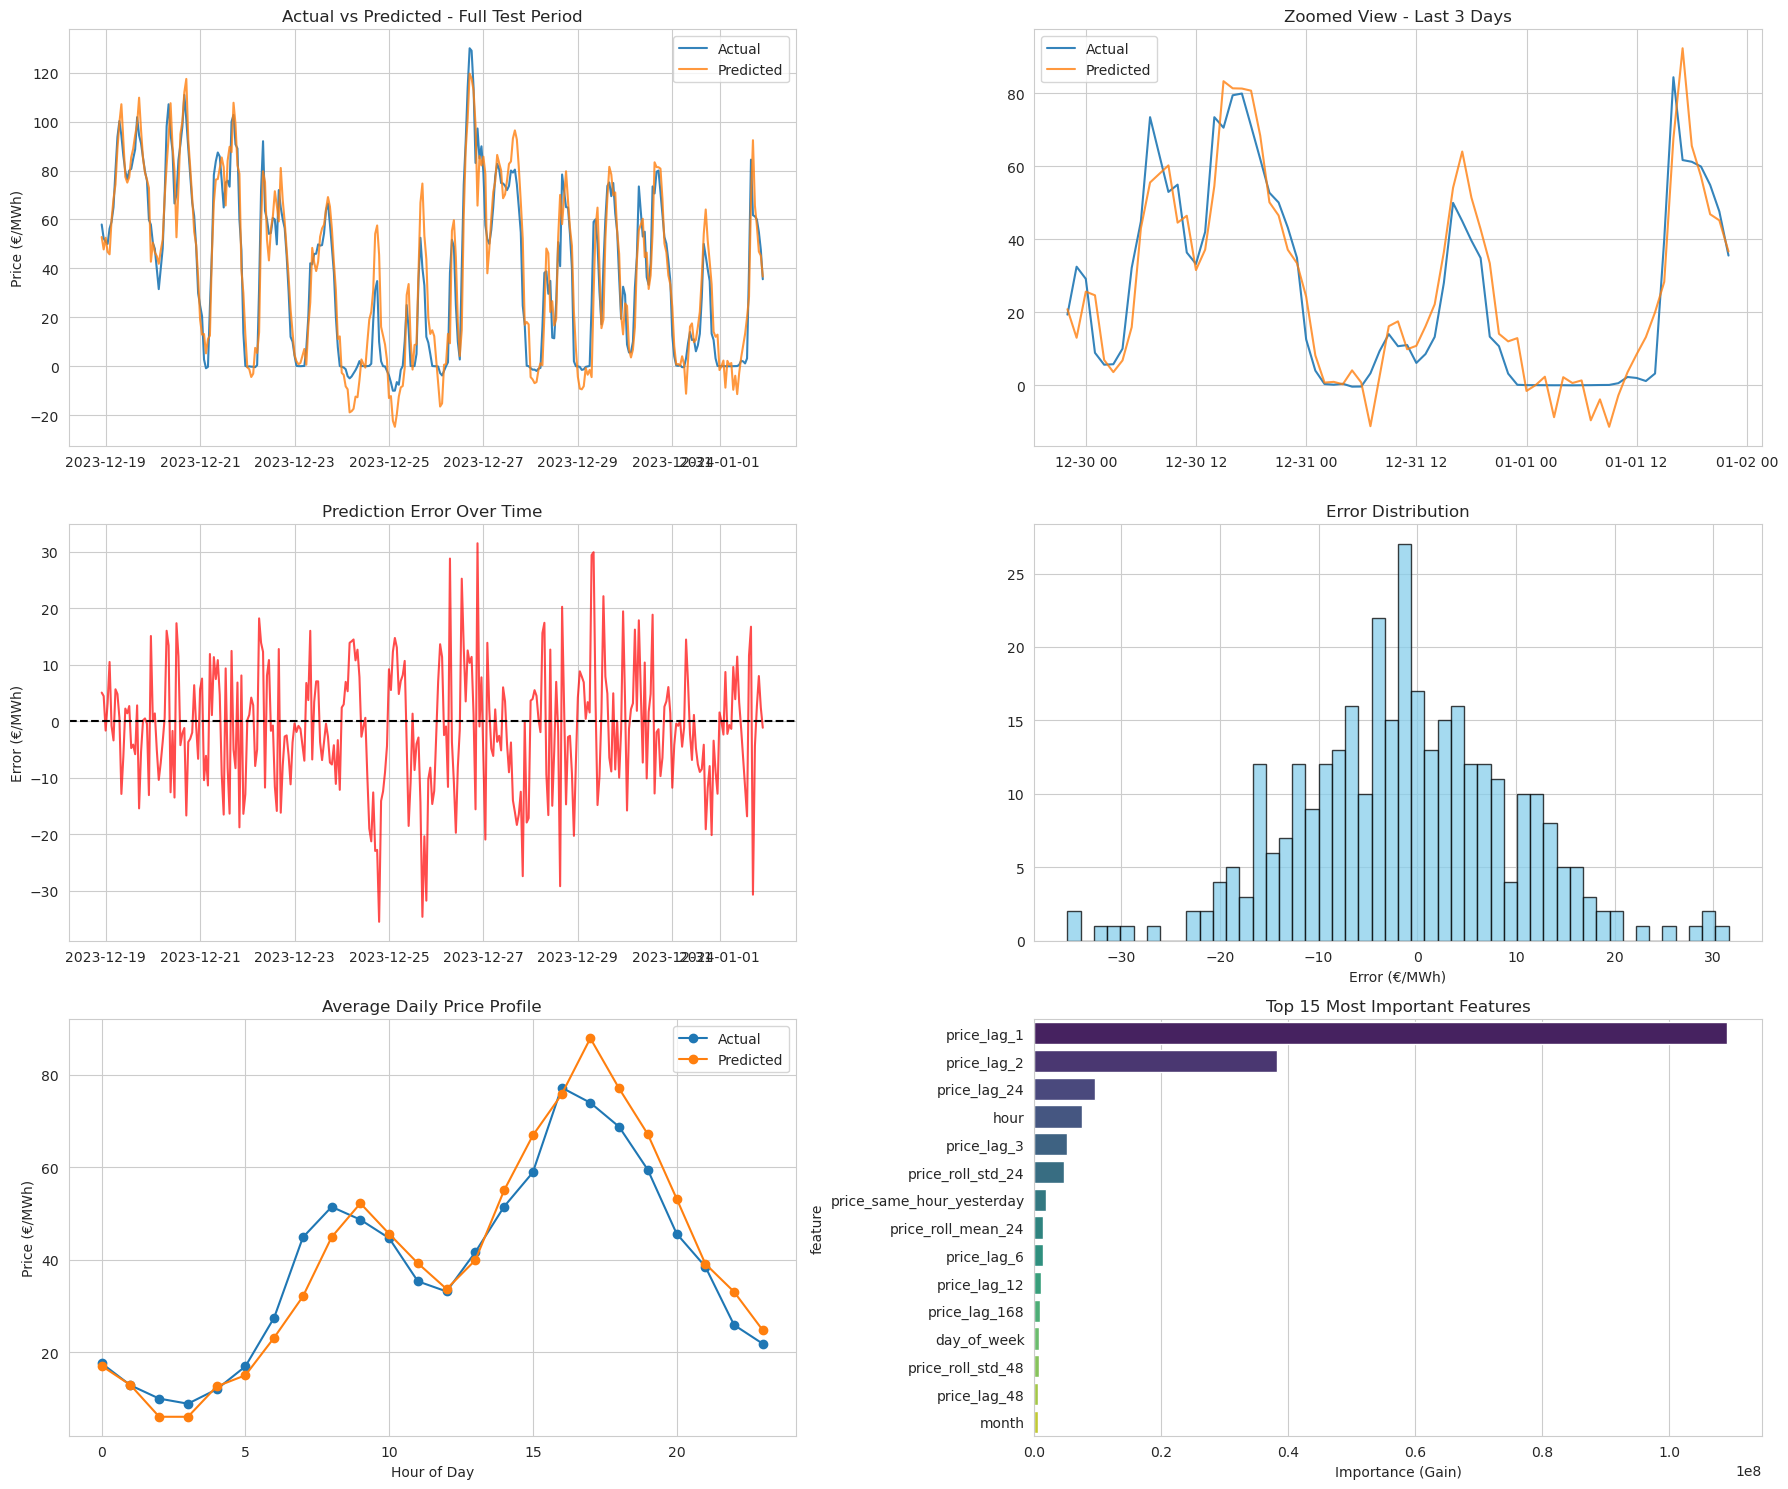

In [ ]:
# ========================== 7. MULTIPLE VISUALIZATIONS ==========================

import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# 1. Actual vs Predicted (Full Test Period)
axes[0, 0].plot(test['timestamp'], y_test, label='Actual', alpha=0.9)
axes[0, 0].plot(test['timestamp'], y_pred, label='Predicted', alpha=0.8)
axes[0, 0].set_title('Actual vs Predicted - Full Test Period')
axes[0, 0].set_ylabel('Price (€/MWh)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Zoomed Last 3 Days
last_3days = test['timestamp'] >= test['timestamp'].max() - pd.Timedelta(days=3)
axes[0, 1].plot(test.loc[last_3days, 'timestamp'], y_test[last_3days], label='Actual', alpha=0.9)
axes[0, 1].plot(test.loc[last_3days, 'timestamp'], y_pred[last_3days], label='Predicted', alpha=0.8)
axes[0, 1].set_title('Zoomed View - Last 3 Days')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Error over time
errors = y_test - y_pred
axes[1, 0].plot(test['timestamp'], errors, color='red', alpha=0.7)
axes[1, 0].axhline(0, color='black', linestyle='--')
axes[1, 0].set_title('Prediction Error Over Time')
axes[1, 0].set_ylabel('Error (€/MWh)')
axes[1, 0].grid(True)

# 4. Error Distribution
axes[1, 1].hist(errors, bins=50, alpha=0.75, color='skyblue', edgecolor='black')
axes[1, 1].set_title('Error Distribution')
axes[1, 1].set_xlabel('Error (€/MWh)')
axes[1, 1].grid(True)

# 5. Daily Profile Comparison
test_copy = test.copy()
test_copy['hour'] = test_copy['timestamp'].dt.hour
test_copy['pred'] = y_pred

daily_profile = test_copy.groupby('hour')[['price', 'pred']].mean()

axes[2, 0].plot(daily_profile.index, daily_profile['price'], label='Actual', marker='o')
axes[2, 0].plot(daily_profile.index, daily_profile['pred'], label='Predicted', marker='o')
axes[2, 0].set_title('Average Daily Price Profile')
axes[2, 0].set_xlabel('Hour of Day')
axes[2, 0].set_ylabel('Price (€/MWh)')
axes[2, 0].legend()
axes[2, 0].grid(True)

# 6. Top 15 Feature Importance
top_features = importance.head(15)
sns.barplot(x='importance', y='feature', data=top_features, ax=axes[2, 1], palette='viridis')
axes[2, 1].set_title('Top 15 Most Important Features')
axes[2, 1].set_xlabel('Importance (Gain)')

plt.tight_layout()
plt.show()

# Next Steps / Improvements

## 1. Hyperparameter Tuning
- Use **Optuna** or **Bayesian Optimization**
- Tune:
  - ARIMA `(p,d,q)`
  - Prophet changepoints
  - learning rate
  - tree depth
  - lag windows

---

## 2. Add Exogenous Features
Incorporate external drivers such as:
- Temperature
- Load forecast
- Renewable generation
- Gas prices

Model becomes:

\[
y(t) = f(y_{t-1}, X_t)
\]

where \(X_t\) represents external variables.

---

## 3. Probabilistic Forecasting
Instead of predicting a single value:

\[
\hat{y} = 52
\]

predict intervals or quantiles:

- P10
- Median
- P90

using **Quantile Regression**.

---

## 4. Time Series Cross-Validation
Avoid random train/test splits.

Use:
- `TimeSeriesSplit`
- Walk-forward validation

Example:

```text
Train: [--------] Test:[--]
Train: [--------------] Test:[--]
Train: [--------------------] Test:[--]

## Advanced: Quantile Regression for Probabilistic Forecasting

Instead of predicting only a single point (mean), we train multiple LightGBM models to predict different **quantiles** (e.g., 5%, 50%, 95%).  

This gives us a **prediction interval** — very useful in energy markets for risk management, trading, and uncertainty estimation.


=== Training Quantile Regression Models for Probabilistic Forecasting ===
Training quantile 5%...
Training quantile 10%...
Training quantile 25%...
Training quantile 50%...
Training quantile 75%...
Training quantile 90%...
Training quantile 95%...

Probabilistic Forecast Results (Last 14 days)


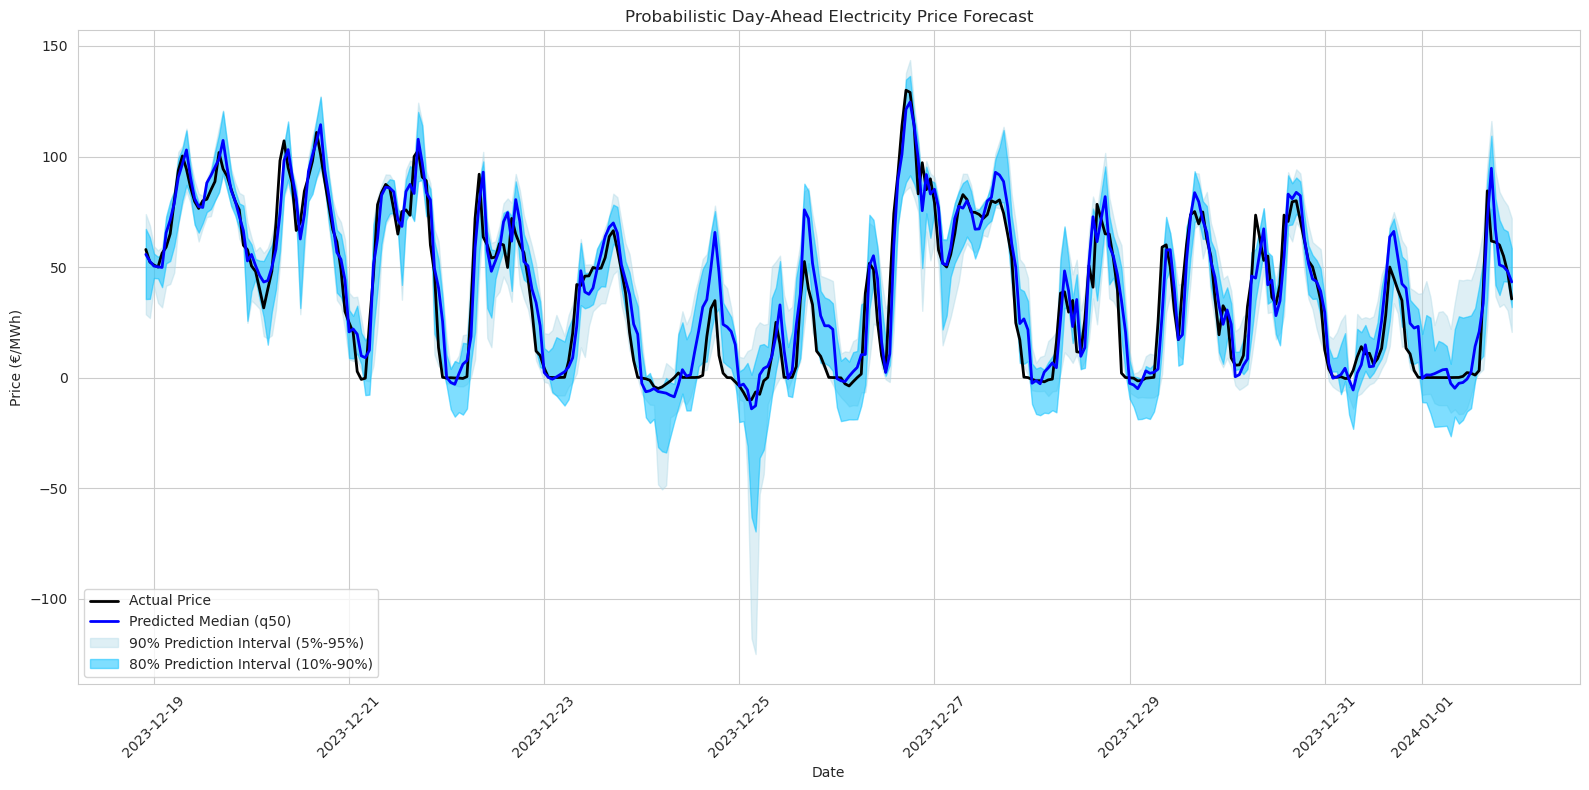

Sample Probabilistic Predictions (last few hours):
                    timestamp  price   q_10   q_50   q_90
262 2023-12-29 22:00:00+00:00  19.35  11.40  32.60  45.96
263 2023-12-29 23:00:00+00:00  32.49   6.25  24.09  36.27
264 2023-12-30 00:00:00+00:00  29.16  17.54  30.57  40.78
265 2023-12-30 01:00:00+00:00   8.88  20.99  24.15  33.58
266 2023-12-30 02:00:00+00:00   5.61   3.37   0.37  11.58
..                        ...    ...    ...    ...    ...
329 2024-01-01 18:00:00+00:00  61.27  41.92  67.11  81.04
330 2024-01-01 19:00:00+00:00  59.97  37.35  50.99  71.31
331 2024-01-01 20:00:00+00:00  54.92  43.54  50.19  67.18
332 2024-01-01 21:00:00+00:00  47.65  43.43  48.08  66.09
333 2024-01-01 22:00:00+00:00  35.55  31.89  43.26  58.52

[72 rows x 5 columns]


In [ ]:
# ========================== QUANTILE REGRESSION (Probabilistic Forecasting) ==========================
print("\n=== Training Quantile Regression Models for Probabilistic Forecasting ===")

quantiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
quantile_models = {}
quantile_predictions = pd.DataFrame(index=test.index)

for q in quantiles:
    print(f"Training quantile {q*100:.0f}%...")
    
    params_q = best_params.copy()  # Use best params from Optuna
    params_q.update({
        'objective': 'quantile',
        'alpha': q,           # This defines which quantile to predict
        'metric': 'quantile',
    })
    
    quantile_models[q] = lgb.train(
        params_q,
        lgb.Dataset(X_train, y_train),
        num_boost_round=1500,
        valid_sets=[lgb.Dataset(X_test, y_test)],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )
    
    # Predict
    quantile_predictions[f'q_{int(q*100)}'] = quantile_models[q].predict(X_test)


# ========================== EVALUATION & VISUALIZATION ==========================
print("\nProbabilistic Forecast Results (Last 14 days)")

# Plot Probabilistic Forecast
plt.figure(figsize=(16, 8))

plt.plot(test['timestamp'], y_test, label='Actual Price', color='black', linewidth=2)

# Plot median (q50)
plt.plot(test['timestamp'], quantile_predictions['q_50'], 
         label='Predicted Median (q50)', color='blue', linewidth=2)

# Plot prediction intervals
plt.fill_between(test['timestamp'], 
                 quantile_predictions['q_5'], 
                 quantile_predictions['q_95'],
                 color='lightblue', alpha=0.4, label='90% Prediction Interval (5%-95%)')

plt.fill_between(test['timestamp'], 
                 quantile_predictions['q_10'], 
                 quantile_predictions['q_90'],
                 color='deepskyblue', alpha=0.5, label='80% Prediction Interval (10%-90%)')

plt.title('Probabilistic Day-Ahead Electricity Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Show sample results for last 5 days
sample = pd.concat([
    test[['timestamp', 'price']].reset_index(drop=True),
    quantile_predictions.reset_index(drop=True)
], axis=1).tail(24*3)   # Last 3 days

print("Sample Probabilistic Predictions (last few hours):")
print(sample[['timestamp', 'price', 'q_10', 'q_50', 'q_90']].round(2))